## <strong> 10. 시계열 데이터 생성 및 조작 </strong>

### <strong> Python 내장 모듈을 이용한 Datetime 생성
---

#### ```datetime```, ```dateutil```: 시계열 처리를 위한 Python 내장 모듈

In [1]:
from datetime import datetime

# datetime 객체 생성
t = datetime(year=2025, month=5, day=7)
t

datetime.datetime(2025, 5, 7, 0, 0)

In [2]:
type(t)

datetime.datetime

In [5]:
# datetime 속성 접근: year
t.year
t.day

7

In [7]:
# 문자열 파싱을 통한 날짜 해석
from dateutil import parser
# 2024-11-05, 11-05, 2024
date = parser.parse("28th of April, 2026")
# date = parser.parse("05-07-2025")

date

datetime.datetime(2025, 4, 28, 0, 0)

#### ```strftime()```: datetime의 속성을 문자열 형태로 출력

In [8]:
# [+] 요일 출력
date.strftime('%A')

'Monday'

In [9]:
# [+] 월 출력
date.strftime('%B')

'April'

### <strong> NumPy를 이용한 Datetime 배열 생성</strong>
---
```datetime64```: ```NumPy```에서 지원하는 datetime 클래스

In [11]:
import numpy as np

# datetime64 배열 객체 생성
dates = np.array(['2025-05-07', '2025-05-08'])
dates

array(['2025-05-07', '2025-05-08'], dtype='<U10')

In [12]:
import numpy as np

# datetime64 배열 객체 생성
dates = np.array(['2025-05-07', '2025-05-08'], dtype=np.datetime64)
dates

array(['2025-05-07', '2025-05-08'], dtype='datetime64[D]')

In [13]:
# datetime64() 메서드를 이용한 객체 생성
date = np.datetime64('2025-05-01')
date

np.datetime64('2025-05-01')

In [15]:
np.arange(31)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30])

In [14]:
# 벡터화 연산을 통한 Datetime 배열 생성
date + np.arange(31) # [0, 1, .. 30]

array(['2025-05-01', '2025-05-02', '2025-05-03', '2025-05-04',
       '2025-05-05', '2025-05-06', '2025-05-07', '2025-05-08',
       '2025-05-09', '2025-05-10', '2025-05-11', '2025-05-12',
       '2025-05-13', '2025-05-14', '2025-05-15', '2025-05-16',
       '2025-05-17', '2025-05-18', '2025-05-19', '2025-05-20',
       '2025-05-21', '2025-05-22', '2025-05-23', '2025-05-24',
       '2025-05-25', '2025-05-26', '2025-05-27', '2025-05-28',
       '2025-05-29', '2025-05-30', '2025-05-31'], dtype='datetime64[D]')

In [16]:
# 분(minute) 단위의 Datetime 객체 생성
t = np.datetime64('2025-05-07 14:30')
t

np.datetime64('2025-05-07T14:30')

In [17]:
# 디폴트 시간 빈도: ms
t = np.datetime64('2025-05-07 14:30:59.99')
t

np.datetime64('2025-05-07T14:30:59.990')

In [18]:
# 시간 빈도를 Nanosecond로 설정
t = np.datetime64('2025-05-07 14:30:59.99', 'ns')
t

np.datetime64('2025-05-07T14:30:59.990000000')

In [19]:
# datetime64 코드: Y, M, D, h...
t = np.datetime64('2025-05-07 14:30:59.99', 'M')
t

np.datetime64('2025-05')

### <strong> Pandas에서의 시계열 처리</strong>
---

In [20]:
import pandas as pd

# [+] to_datetime() 함수를 이용한 Timestamp 객체 생성 
date = pd.to_datetime('2004-03-22') # 본인 생일로 입력
date

Timestamp('2004-03-22 00:00:00')

In [21]:
# [+] 요일 출력
type(date)

pandas._libs.tslibs.timestamps.Timestamp

In [22]:
# [+] 요일 출력
date.strftime('%A')

'Monday'

In [23]:
date+ np.arange(30)

TypeError: Addition/subtraction of integers and integer-arrays with Timestamp is no longer supported.  Instead of adding/subtracting `n`, use `n * obj.freq`

In [24]:
# NumPy 스타일의 배열 연산
date + pd.to_timedelta(np.arange(7))

DatetimeIndex([          '2004-03-22 00:00:00',
               '2004-03-22 00:00:00.000000001',
               '2004-03-22 00:00:00.000000002',
               '2004-03-22 00:00:00.000000003',
               '2004-03-22 00:00:00.000000004',
               '2004-03-22 00:00:00.000000005',
               '2004-03-22 00:00:00.000000006'],
              dtype='datetime64[ns]', freq=None)

In [25]:
date + pd.to_timedelta(np.arange(7), unit='D')

DatetimeIndex(['2004-03-22', '2004-03-23', '2004-03-24', '2004-03-25',
               '2004-03-26', '2004-03-27', '2004-03-28'],
              dtype='datetime64[ns]', freq=None)

#### <strong> 시계열 생성

In [29]:
# DatetimeIndex 객체 생성
ind = pd.DatetimeIndex(['2022-10-27', '2022-10-28', '2022-10-29', '2022-10-30',
                        '2022-10-31', '2022-11-01', '2022-11-02'])
ind

DatetimeIndex(['2022-10-27', '2022-10-28', '2022-10-29', '2022-10-30',
               '2022-10-31', '2022-11-01', '2022-11-02'],
              dtype='datetime64[ns]', freq=None)

In [31]:
ser = pd.Series([0, 1, 2, 3, 4, 5, 6])
ser

0    0
1    1
2    2
3    3
4    4
5    5
6    6
dtype: int64

In [36]:
# [+] 시계열 인덱싱 적용
ser = pd.Series([0, 1, 2, 3, 4, 5, 6], index = ind )
ser

2022-10-27    0
2022-10-28    1
2022-10-29    2
2022-10-30    3
2022-10-31    4
2022-11-01    5
2022-11-02    6
dtype: int64

<Axes: >

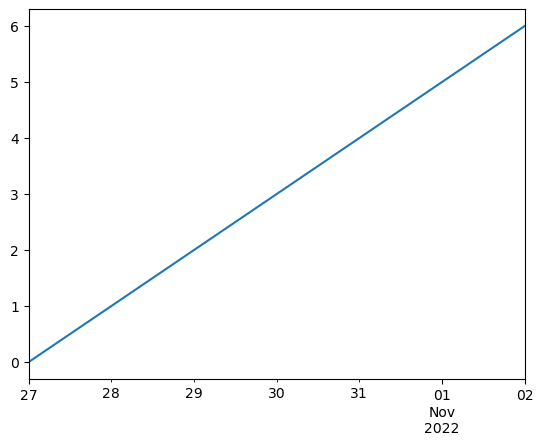

In [34]:
ser.plot()

In [ ]:
ser.index

In [37]:
# [+] 인덱싱
ser['2022-10-30']

np.int64(3)

In [38]:
# [+] 슬라이싱
ser['2022-10-28':'2022-11-01']

2022-10-28    1
2022-10-29    2
2022-10-30    3
2022-10-31    4
2022-11-01    5
dtype: int64

In [39]:
# [+] 데이터 선택
ser[1]

/var/folders/jp/w5rb01j17_z0rkp53fzfqcvr0000gn/T/ipykernel_85264/2354827133.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ser[1]


np.int64(1)

#### <strong>시계열 생성: 데이터셋의 타임스탬프 변수를 인덱스로 설정하기</strong>

In [40]:
path = "./data/"
filename = "AirQualityUCI_refined.csv"

df = pd.read_csv(path + filename)
df.head()

,Datetime,CO(GT),PT08.S1(CO),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),RH,AH,C6H6(GT)
0,2004-03-10 18:00:00,2.6,1360.0,1046.0,166.0,1056.0,113.0,1692.0,1268.0,48.9,0.7578,11.9
1,2004-03-10 19:00:00,2.0,1292.0,955.0,103.0,1174.0,92.0,1559.0,972.0,47.7,0.7255,9.4
2,2004-03-10 20:00:00,2.2,1402.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,54.0,0.7502,9.0
3,2004-03-10 21:00:00,2.2,1376.0,948.0,172.0,1092.0,122.0,1584.0,1203.0,60.0,0.7867,9.2
4,2004-03-10 22:00:00,1.6,1272.0,836.0,131.0,1205.0,116.0,1490.0,1110.0,59.6,0.7888,6.5


<strong>방법 1: </strong>DataFrame.set_index()

In [41]:
df.set_index('Datetime', inplace=True) # 특정 컬럼을 인덱스로 설정
df['2004-03':'2004-12']

,CO(GT),PT08.S1(CO),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),RH,AH,C6H6(GT)
Datetime,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,1046.0,166.0,1056.0,113.0,1692.0,1268.0,48.9,0.7578,11.9
2004-03-10 19:00:00,2.0,1292.0,955.0,103.0,1174.0,92.0,1559.0,972.0,47.7,0.7255,9.4
2004-03-10 20:00:00,2.2,1402.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,54.0,0.7502,9.0
2004-03-10 21:00:00,2.2,1376.0,948.0,172.0,1092.0,122.0,1584.0,1203.0,60.0,0.7867,9.2
2004-03-10 22:00:00,1.6,1272.0,836.0,131.0,1205.0,116.0,1490.0,1110.0,59.6,0.7888,6.5
...,...,...,...,...,...,...,...,...,...,...,...
2004-11-30 19:00:00,6.3,1408.0,1502.0,692.0,640.0,178.0,1843.0,1598.0,64.3,0.8789,28.0
2004-11-30 20:00:00,6.8,1471.0,1559.0,731.0,605.0,168.0,1939.0,1669.0,68.0,0.9207,30.3
2004-11-30 21:00:00,4.1,1157.0,1063.0,491.0,905.0,160.0,1394.0,1223.0,73.9,0.9502,12.4


<strong>방법 2: </strong>Pandas.read_csv(index_col=...)

In [42]:
df = pd.read_csv(path + filename, index_col='Datetime')
df.head()

,CO(GT),PT08.S1(CO),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),RH,AH,C6H6(GT)
Datetime,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,1046.0,166.0,1056.0,113.0,1692.0,1268.0,48.9,0.7578,11.9
2004-03-10 19:00:00,2.0,1292.0,955.0,103.0,1174.0,92.0,1559.0,972.0,47.7,0.7255,9.4
2004-03-10 20:00:00,2.2,1402.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,54.0,0.7502,9.0
2004-03-10 21:00:00,2.2,1376.0,948.0,172.0,1092.0,122.0,1584.0,1203.0,60.0,0.7867,9.2
2004-03-10 22:00:00,1.6,1272.0,836.0,131.0,1205.0,116.0,1490.0,1110.0,59.6,0.7888,6.5


#### <strong> 시계열 관련 Pandas의 데이터 구조

In [43]:
# Timestamp와 DatetimeIndex
dates = pd.to_datetime([datetime(2015, 7, 3),
                      "4th of July, 2015",
                      '2015-Jul-6',
                      '07-07-2015',
                      '20150708'])
print(dates)

DatetimeIndex(['2015-07-03', '2015-07-04', '2015-07-06', '2015-07-07',
               '2015-07-08'],
              dtype='datetime64[ns]', freq=None)


In [44]:
# to_period(): DatetimeIndex -> PeriodIndex 변환
dates.to_period('W')

PeriodIndex(['2015-06-29/2015-07-05', '2015-06-29/2015-07-05',
             '2015-07-06/2015-07-12', '2015-07-06/2015-07-12',
             '2015-07-06/2015-07-12'],
            dtype='period[W-SUN]')

In [46]:
dates

DatetimeIndex(['2015-07-03', '2015-07-04', '2015-07-06', '2015-07-07',
               '2015-07-08'],
              dtype='datetime64[ns]', freq=None)

In [45]:
# [+] TimedeltaIndex 생성
dates-dates[0]

TimedeltaIndex(['0 days', '1 days', '3 days', '4 days', '5 days'], dtype='timedelta64[ns]', freq=None)

#### <strong> 정규 시퀀스 </strong>

In [48]:
# [+] pd.date_range()를 이용한 정규 시퀀스 생성
pd.date_range('2026-01-01', '2026-04-28')

DatetimeIndex(['2026-01-01', '2026-01-02', '2026-01-03', '2026-01-04',
               '2026-01-05', '2026-01-06', '2026-01-07', '2026-01-08',
               '2026-01-09', '2026-01-10',
               ...
               '2026-04-19', '2026-04-20', '2026-04-21', '2026-04-22',
               '2026-04-23', '2026-04-24', '2026-04-25', '2026-04-26',
               '2026-04-27', '2026-04-28'],
              dtype='datetime64[ns]', length=118, freq='D')

In [50]:
# [+] Period 값을 이용
pd.date_range('2022-10-27', periods = 100)

DatetimeIndex(['2022-10-27', '2022-10-28', '2022-10-29', '2022-10-30',
               '2022-10-31', '2022-11-01', '2022-11-02', '2022-11-03',
               '2022-11-04', '2022-11-05', '2022-11-06', '2022-11-07',
               '2022-11-08', '2022-11-09', '2022-11-10', '2022-11-11',
               '2022-11-12', '2022-11-13', '2022-11-14', '2022-11-15',
               '2022-11-16', '2022-11-17', '2022-11-18', '2022-11-19',
               '2022-11-20', '2022-11-21', '2022-11-22', '2022-11-23',
               '2022-11-24', '2022-11-25', '2022-11-26', '2022-11-27',
               '2022-11-28', '2022-11-29', '2022-11-30', '2022-12-01',
               '2022-12-02', '2022-12-03', '2022-12-04', '2022-12-05',
               '2022-12-06', '2022-12-07', '2022-12-08', '2022-12-09',
               '2022-12-10', '2022-12-11', '2022-12-12', '2022-12-13',
               '2022-12-14', '2022-12-15', '2022-12-16', '2022-12-17',
               '2022-12-18', '2022-12-19', '2022-12-20', '2022-12-21',
      

In [53]:
# 빈도 변경
pd.date_range('2022-10-27', periods=12, freq='h')

DatetimeIndex(['2022-10-27 00:00:00', '2022-10-27 01:00:00',
               '2022-10-27 02:00:00', '2022-10-27 03:00:00',
               '2022-10-27 04:00:00', '2022-10-27 05:00:00',
               '2022-10-27 06:00:00', '2022-10-27 07:00:00',
               '2022-10-27 08:00:00', '2022-10-27 09:00:00',
               '2022-10-27 10:00:00', '2022-10-27 11:00:00'],
              dtype='datetime64[ns]', freq='h')

In [52]:
# pd.period_range()
pd.period_range('2015-07', periods=8, freq='M')

PeriodIndex(['2015-07', '2015-08', '2015-09', '2015-10', '2015-11', '2015-12',
             '2016-01', '2016-02'],
            dtype='period[M]')

In [54]:
# Timestamp vs. Period
period = pd.Period('2022-10-27')
timestamp = pd.Timestamp('2022-10-27 09:30')

print(period.start_time < timestamp < period.end_time)

print(period.start_time)

print(period.end_time)

True
2022-10-27 00:00:00
2022-10-27 23:59:59.999999999


In [ ]:
# pd.timedelta_range()
pd.timedelta_range(0, periods=10, freq='H')

| Code   | Description         | Code   | Description          |
|--------|---------------------|--------|----------------------|
| ``D``  | Calendar day        | ``B``  | Business day         |
| ``W``  | Weekly              |   -    |                      |
| ``M``  | Month end           | ``BM`` | Business month end   |
| ``Q``  | Quarter end         | ``BQ`` | Business quarter end |
| ``A``  | Year end            | ``BA`` | Business year end    |
| ``H``  | Hours               | ``BH`` | Business hours       |
| ``T``  | Minutes             |   -    |                      |
| ``S``  | Seconds             |   -    |                      |
| ``L``  | Milliseonds         |   -    |                      |
| ``U``  | Microseconds        |   -    |                      |
| ``N``  | nanoseconds         |   -    |                      |

#### <strong> 빈도 및 오프셋

In [75]:
# 빈도 코드
pd.date_range('2022-11-01', periods=10, freq='h')

DatetimeIndex(['2022-11-01 00:00:00', '2022-11-01 01:00:00',
               '2022-11-01 02:00:00', '2022-11-01 03:00:00',
               '2022-11-01 04:00:00', '2022-11-01 05:00:00',
               '2022-11-01 06:00:00', '2022-11-01 07:00:00',
               '2022-11-01 08:00:00', '2022-11-01 09:00:00'],
              dtype='datetime64[ns]', freq='h')

In [74]:
# 빈도, M: 월말
(pd.date_range('2022-11-01', periods=10, freq="ME"))

DatetimeIndex(['2022-11-30', '2022-12-31', '2023-01-31', '2023-02-28',
               '2023-03-31', '2023-04-30', '2023-05-31', '2023-06-30',
               '2023-07-31', '2023-08-31'],
              dtype='datetime64[ns]', freq='ME')

In [73]:
# 빈도, BM: 비즈니스 기준 월말
pd.date_range('2022-11-01', periods=10, freq="BME")

DatetimeIndex(['2022-11-30', '2022-12-30', '2023-01-31', '2023-02-28',
               '2023-03-31', '2023-04-28', '2023-05-31', '2023-06-30',
               '2023-07-31', '2023-08-31'],
              dtype='datetime64[ns]', freq='BME')

In [70]:
# 접미사 'S': 시작 일시를 기준으로 시퀀스 생성
pd.date_range('2022-11-01', periods=10, freq='MS')

DatetimeIndex(['2022-11-01', '2022-12-01', '2023-01-01', '2023-02-01',
               '2023-03-01', '2023-04-01', '2023-05-01', '2023-06-01',
               '2023-07-01', '2023-08-01'],
              dtype='datetime64[ns]', freq='MS')

In [77]:
# 빈도 코드 조합
pd.date_range('2026-04-28 09:30:00', periods=9, freq='1h30min')

DatetimeIndex(['2026-04-28 09:30:00', '2026-04-28 11:00:00',
               '2026-04-28 12:30:00', '2026-04-28 14:00:00',
               '2026-04-28 15:30:00', '2026-04-28 17:00:00',
               '2026-04-28 18:30:00', '2026-04-28 20:00:00',
               '2026-04-28 21:30:00'],
              dtype='datetime64[ns]', freq='90min')

In [72]:
# 오프셋
from pandas.tseries.offsets import DateOffset
ts = pd.Timestamp('2023-11-07 09:30:00')
ts + DateOffset(hours=-40)

Timestamp('2023-11-05 17:30:00')

In [78]:
# 오프셋(minus)
ts - DateOffset(years=73, months=4, days=12, hours=5, minutes=10, seconds=00)

Timestamp('1950-06-25 04:20:00')